### **RETAIL SALES DATA ANALYSIS**

---

## Section 1 - Data Preparation

### Data Loading

In [335]:
import pandas as pd

In [336]:
df = pd.read_csv("Data/sales data-set.csv")

In [337]:
import pandas as pd

In [338]:
import os

os.listdir()

['.git',
 '.gitignore',
 '.python-version',
 '.slugignore',
 '.venv',
 'Data',
 'jupyter_notebooks',
 'Procfile',
 'README.md',
 'requirements.txt',
 'setup.sh']

In [339]:
[file for file in os.listdir() if "sales" in file.lower()]

[]

In [340]:
os.getcwd()

'c:\\Users\\yetun\\Desktop\\Code Institute Registration Documents for Level 3 Data Analysis with AI\\Git Repository\\Data Analytics Projects\\retail-sales-analysis'

In [341]:
os.listdir("..")

['retail-sales-analysis']

In [344]:
import os
print(os.getcwd())


c:\Users\yetun\Desktop\Code Institute Registration Documents for Level 3 Data Analysis with AI\Git Repository\Data Analytics Projects\retail-sales-analysis


In [345]:
os.listdir("Data")

['Features data set.csv',
 'retail_sales_cleaned.csv',
 'sales data-set.csv',
 'stores data-set.csv']

In [346]:
df = pd.read_csv("Data/sales data-set.csv")

In [55]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [56]:
df.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [57]:
(df['Weekly_Sales'] < 0).sum()

np.int64(1285)

In [58]:
df[df['Weekly_Sales'] < 0].head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday
846,1,6,10/08/2012,-139.65,False
2384,1,18,04/05/2012,-1.27,False
6048,1,47,19/02/2010,-863.00,False
6049,1,47,12/03/2010,-698.00,False
6051,1,47,08/10/2010,-58.00,False
6056,1,47,08/04/2011,-298.00,False
6057,1,47,08/07/2011,-198.00,False
6061,1,47,14/10/2011,-498.00,False
6062,1,47,23/12/2011,-498.00,False
6063,1,47,17/02/2012,-198.00,False


In [59]:
negative_sales = df[df['Weekly_Sales'] < 0]

negative_sales.shape

(1285, 5)

In [60]:
negative_sales['Weekly_Sales'].sum()

np.float64(-88161.56)

In [61]:
negative_sales.groupby('Dept')['Weekly_Sales'].count().sort_values(ascending=False).head(10)

Dept
47    254
18    180
54    146
19     87
94     77
80     68
49     67
59     44
72     34
78     33
Name: Weekly_Sales, dtype: int64

In [62]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 13.3 MB


In [64]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(1), int64(2)
memory usage: 13.3 MB


In [71]:
negative_sales.groupby(negative_sales['Date'].dt.year)['Weekly_Sales'].count()

Date
2010    390
2011    483
2012    412
Name: Weekly_Sales, dtype: int64

In [67]:
negative_sales = df[df['Weekly_Sales'] < 0]

In [70]:
negative_sales['Date'].dtype

dtype('<M8[us]')

In [69]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [72]:
negative_sales = df[df['Weekly_Sales'] < 0]

In [73]:
negative_sales['Date'].dtype

dtype('<M8[us]')

In [74]:
negative_sales.groupby(negative_sales['Date'].dt.year)['Weekly_Sales'].count()

Date
2010    390
2011    483
2012    412
Name: Weekly_Sales, dtype: int64

In [75]:
df.duplicated().sum()

np.int64(0)

In [76]:
df['Date'].min(), df['Date'].max()

(Timestamp('2010-02-05 00:00:00'), Timestamp('2012-10-26 00:00:00'))

In [77]:
df['Store'].nunique(), df['Dept'].nunique()

(45, 81)

In [78]:
df['IsHoliday'].value_counts()

IsHoliday
False    391909
True      29661
Name: count, dtype: int64

In [79]:
df.groupby('IsHoliday')['Weekly_Sales'].mean()

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

In [80]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
store_sales.head(10)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

In [81]:
import matplotlib.pyplot as plt

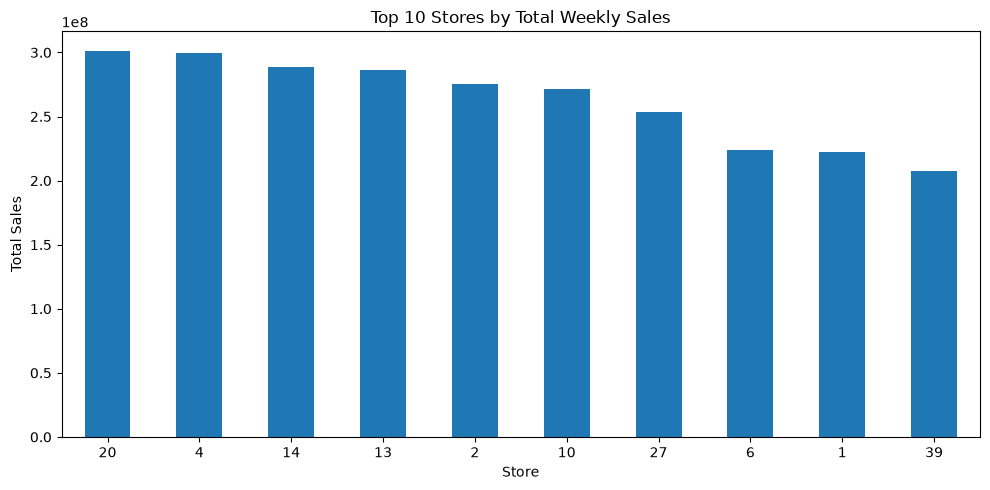

In [82]:
store_sales.head(10).plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 Stores by Total Weekly Sales',
)

plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [83]:
store_sales.tail(10).sort_values()

Store
33    37160221.96
44    43293087.84
5     45475688.90
36    53412214.97
38    55159626.42
3     57586735.07
30    62716885.12
37    74202740.32
16    74252425.40
29    77141554.31
Name: Weekly_Sales, dtype: float64

In [84]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Weekly_Sales'].sum()

monthly_sales.head()

Date
2010-02    1.903330e+08
2010-03    1.819198e+08
2010-04    2.314124e+08
2010-05    1.867109e+08
2010-06    1.922462e+08
Freq: M, Name: Weekly_Sales, dtype: float64

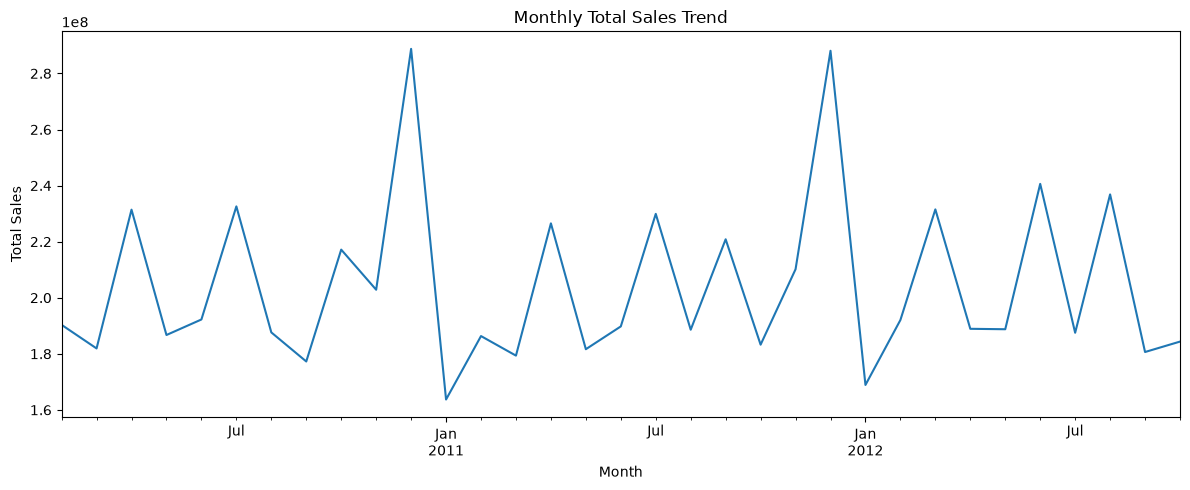

In [85]:
monthly_sales.plot(
    kind='line',
    figsize=(12, 5),
    title='Monthly Total Sales Trend'
)

plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [86]:
monthly_sales.idxmax(), monthly_sales.max()

(Period('2010-12', 'M'), np.float64(288760532.72))

In [87]:
monthly_sales.idxmin(), monthly_sales.min()

(Period('2011-01', 'M'), np.float64(163703966.83))

In [88]:
dept_sales = df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)

dept_sales.head(10)

Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
40    2.889360e+08
2     2.806112e+08
91    2.167817e+08
13    1.973216e+08
8     1.942808e+08
Name: Weekly_Sales, dtype: float64

In [89]:
dept_sales.tail(10).sort_values()

Dept
47      -4962.93
43         14.32
39        177.98
78       1714.71
51      30572.83
45      44937.63
77      49344.27
99     358149.85
54     516294.63
60    2005020.96
Name: Weekly_Sales, dtype: float64

In [90]:
df[df['Dept'] == 47]['Weekly_Sales'].describe()

count     646.000000
mean       -7.682554
std       307.882645
min     -3924.000000
25%       -58.000000
50%        17.985000
75%        70.000000
max      1098.000000
Name: Weekly_Sales, dtype: float64

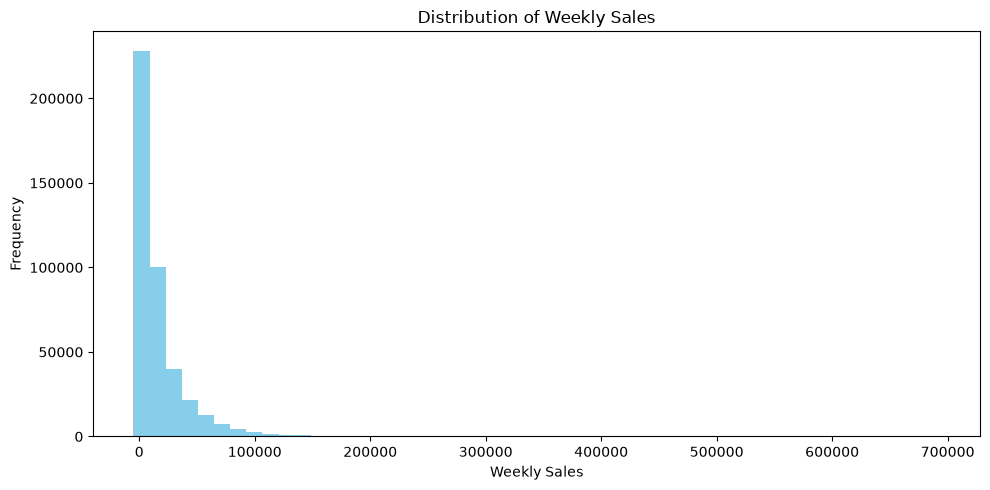

In [91]:
df['Weekly_Sales'].plot(
    kind='hist',
    bins=50,
    figsize=(10, 5),
    title='Distribution of Weekly Sales',
    color='skyblue'
)

plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [92]:
average_store_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)

average_store_sales.head(10)

Store
20    29508.301592
4     29161.210415
14    28784.851727
13    27355.136891
2     26898.070031
10    26332.303819
27    24826.984536
6     21913.243624
1     21710.543621
39    21000.763562
Name: Weekly_Sales, dtype: float64

In [93]:
annual_sales = df.groupby(df['Date'].dt.year)['Weekly_Sales'].sum()

annual_sales

Date
2010    2.288886e+09
2011    2.448200e+09
2012    2.000133e+09
Name: Weekly_Sales, dtype: float64

In [94]:
((annual_sales[2011] - annual_sales[2010]) / annual_sales[2010]) * 100

np.float64(6.960323867552779)

In [95]:
monthly_average = df.groupby(
    df['Date'].dt.month
)['Weekly_Sales'].mean()

monthly_average

Date
1     14126.075111
2     16008.779217
3     15416.657597
4     15650.338357
5     15776.337202
6     16326.137002
7     15861.419650
8     16062.516933
9     15095.886154
10    15243.855576
11    17491.031424
12    19355.702141
Name: Weekly_Sales, dtype: float64

In [96]:
holiday_store_sales = (
    df[df['IsHoliday'] == True]
    .groupby('Store')['Weekly_Sales']
    .mean()
    .sort_values(ascending=False)
)

holiday_store_sales.head(10)

Store
20    31106.985906
4     30854.231417
14    30164.765263
10    29195.524157
2     28798.710526
13    28593.285602
27    26318.487872
6     23313.563481
1     23039.386667
39    22254.339742
Name: Weekly_Sales, dtype: float64

In [97]:
holiday_comparison = df.groupby(
    ['Store', 'IsHoliday']
)['Weekly_Sales'].mean().unstack()

holiday_comparison.head()

IsHoliday,False,True
Store,,
1,21609.634733,23039.386667
2,26753.864227,28798.710526
3,6332.098604,6916.446288
4,29032.260570,30854.231417
5,5010.249172,5617.212609


In [98]:
holiday_comparison['Holiday_Increase_%'] = (
    (holiday_comparison[True] - holiday_comparison[False])
    / holiday_comparison[False]
) * 100

holiday_comparison.sort_values(
    'Holiday_Increase_%',
    ascending=False
).head(10)

IsHoliday,False,True,Holiday_Increase_%
Store,,,
35,13631.736739,16083.060734,17.982478
7,8254.246774,9730.828726,17.888755
12,14731.304140,16663.842167,13.118581
15,8920.611276,10077.118659,12.964441
29,8088.309482,9086.195943,12.337392
5,5010.249172,5617.212609,12.114436
10,26116.166656,29195.524157,11.791001
28,18567.759341,20645.874372,11.192061
17,12862.113716,14179.406237,10.241649


In [99]:
holiday_comparison['Holiday_Increase_%'].mean()

np.float64(6.733147596441419)

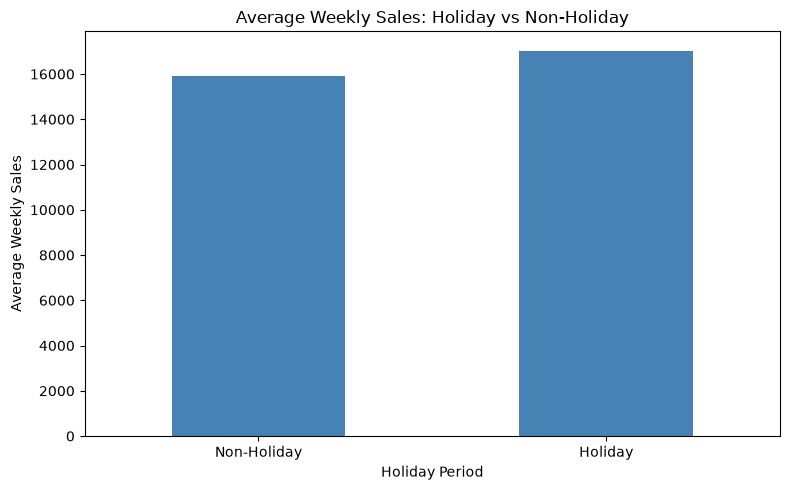

In [100]:
holiday_avg_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()

holiday_avg_sales.plot(
    kind='bar',
    figsize=(8, 5),
    title='Average Weekly Sales: Holiday vs Non-Holiday',
    color='steelblue'
)

plt.xlabel('Holiday Period')
plt.ylabel('Average Weekly Sales')
plt.xticks(
    ticks=[0, 1],
    labels=['Non-Holiday', 'Holiday'],
    rotation=0
)
plt.tight_layout()
plt.show()

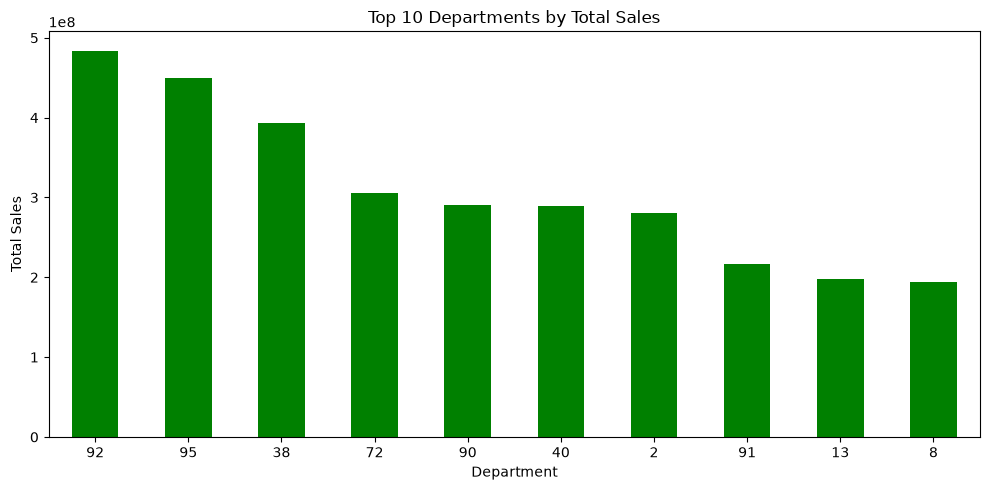

In [101]:
dept_sales.head(10).plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 Departments by Total Sales',
    color='green'
)

plt.xlabel('Department')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

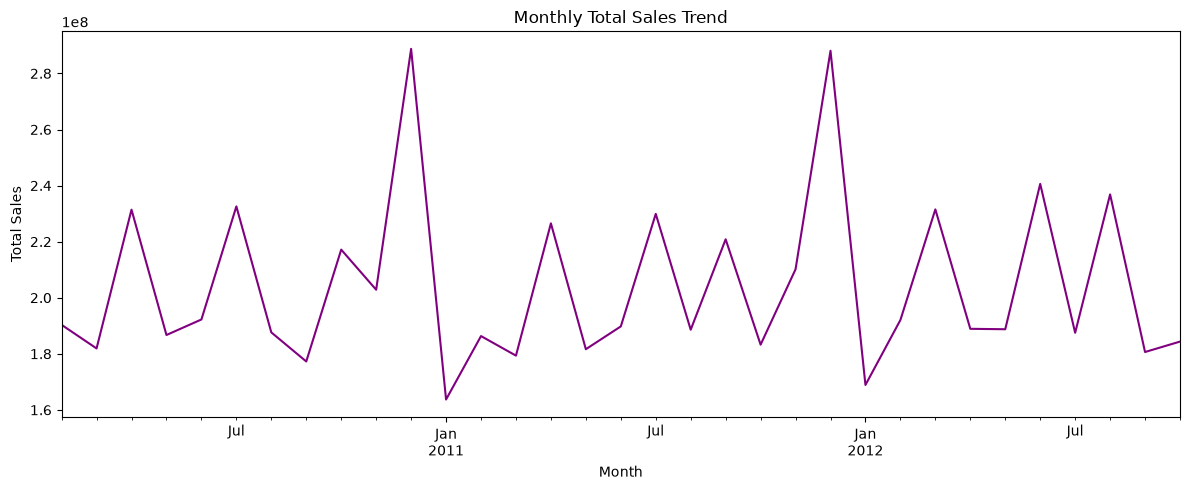

In [102]:
monthly_sales.plot(
    kind='line',
    figsize=(12, 5),
    title='Monthly Total Sales Trend',
    color='purple'
)

plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

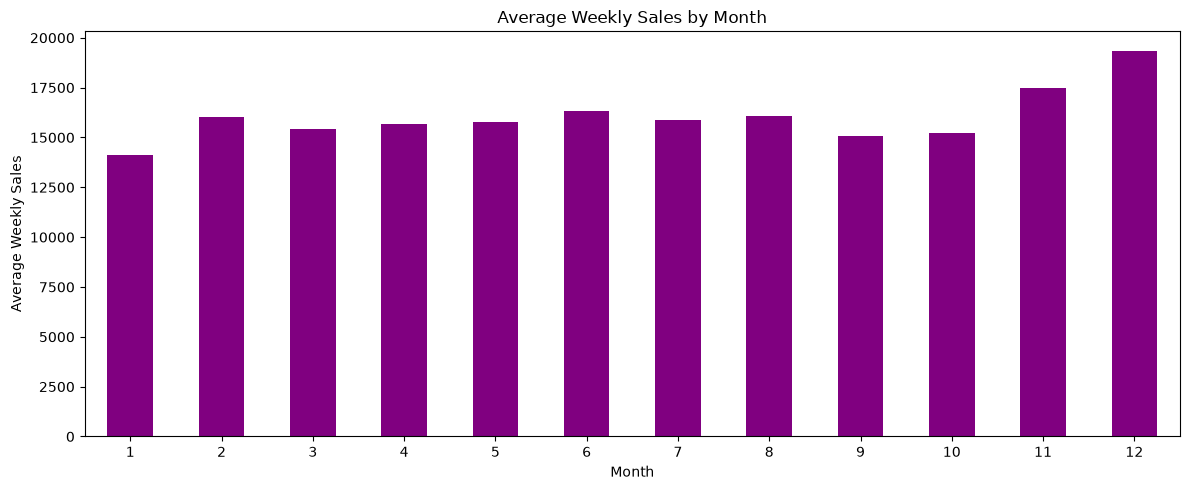

In [103]:
monthly_average.plot(
    kind='bar',
    figsize=(12, 5),
    title='Average Weekly Sales by Month',
    color='purple'
)

plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [104]:
import pandas as pd
df = pd.read_csv("Data/sales data-set.csv")

----------------------------------------------------------------

### A.
- Aim
- Project Purpose and Target Audience
- Application of Data Analytics
- Data Analytics and AI Opportunity
- AI Assistance
- Generative AI for Data Storytelling

### Aim
* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

This project shows weekly sales from various departments and stores. The goal is to understand sales trends in order to identify the best-performing departments and stores. Another objective is examining how different months and holidays impact sales.

### Project Purpose and Target Audience
The purpose of this project is to analyze retail sales data and identify patterns in sales performance across different departments, stores, months, and holiday seasons. The analysis is intended to suggest that further investigation may be necessary.

Retail managers and business decision-makers who must comprehend sales performance and use data to support decisions about stock, promotions, and store or department performance are the primary target audience.

### Application of Data Analytics

Retail companies can use data analytics to better understand sales performance and make decisions. Businesses can use it to determine sales trends, compare departmental and store performance, comprehend seasonal and holiday sales patterns, and spot odd sales records.

For instance, a company can determine which departments and stores do well by analyzing past sales data. Additionally, sales data can be utilized for stock planning, customer analysis, sales forecasting, and promotional opportunity identification.

In this project, retail sales were analyzed by year, month, store, department, and holiday periods using data analytics. The findings provide helpful data that can assist in making evidence-based business decisions.

### Data Analytics and AI Opportunity

In addition to using AI to forecast future sales, data analytics can assist the company in understanding past sales performance. To predict future demand, an AI-powered sales forecasting system could make use of department performance, store data, historical sales data, and holiday trends.

This could assist the company in planning stock levels, lowering the possibility that products won't be available, and getting ready for times when demand is anticipated to rise. AI may also be able to spot odd sales trends that require more research.

AI is seen in this project as a chance to support better business decisions and enhance future sales forecasting.

### AI Assistance

Throughout this project, generative AI was utilized as a support tool to assist with comprehending Python code, resolving issues, coming up with concepts for data analysis, and choosing appropriate visualizations.

AI was also utilized to organize the results into concise insights, suggestions, and a conclusion. Using the real dataset, the code and recommendations from AI were examined and tested in the Jupyter Notebook.

Based on the data, the learner verified the final analysis, findings, and business decisions.

### Generative AI for Data Storytelling

Generative AI was used to support the communication of the analysis results in a clear and understandable way. The analysis results were reviewed and used to develop key findings, insights, recommendations and the conclusion.

The visualisations helped communicate important patterns in the data, such as changes in yearly and monthly sales, differences between stores and departments, and the effect of holiday periods on sales.

The final findings and recommendations were checked against the analysis results to ensure that they accurately represented the data.


-------------------------------------------------------------

### B. NOTEBOOK SETUP


- Change Working Directory
- Input/Output
- Additional Comments

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [105]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\yetun\\Desktop\\Code Institute Registration Documents for Level 3 Data Analysis with AI\\Git Repository\\Data Analytics Projects\\retail-sales-analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [106]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [107]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\yetun\\Desktop\\Code Institute Registration Documents for Level 3 Data Analysis with AI\\Git Repository\\Data Analytics Projects\\retail-sales-analysis'

### Inputs

Write down which data or information you need to run the notebook 

The project uses three datasets: Sales, Features and Stores.

Sales data set: Contains weekly sales records for each store and department, including date and holiday information.
Features data set: Contains information such as temperature, fuel price, markdowns, CPI and unemployment.
Stores data set: Contains information about each store, including store type and size.

### Outputs

Write here which files, code or artefacts you generate by the end of the notebook 

The analysis produced insights into retail sales trends across different stores, departments, years and holiday periods. Visualisations were used to identify patterns in weekly sales and compare sales performance. The analysis also highlighted unusual negative sales records and differences in sales performance between stores and departments.

### Additional Comments

If you have any additional comments that don't fit in the previous bullets, please state them here. 

The analysis was completed using Python, Pandas, Matplotlib and Seaborn. The findings provide useful insights into sales patterns and can support the business in making informed decisions about sales, promotions and store performance.

---------------------------------------------------------------

### SECTION 1 - DATA PREPARATION
### Content

- Data Loading
- Initial Data Exploration
- Data Cleaning
- Data Management and Processing
- Data Handling Rationale

### Data Loading

In [205]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\yetun\Desktop\Code Institute Registration Documents for Level 3 Data Analysis with AI\Git Repository\Data Analytics Projects\retail-sales-analysis
['.git', '.gitignore', '.python-version', '.slugignore', '.venv', 'Data', 'jupyter_notebooks', 'Procfile', 'README.md', 'requirements.txt', 'setup.sh']


In [204]:
os.listdir("Data")

['Features data set.csv',
 'retail_sales_cleaned.csv',
 'sales data-set.csv',
 'stores data-set.csv']

In [202]:
import os
print(os.path.abspath("Data"))

c:\Users\yetun\Desktop\Code Institute Registration Documents for Level 3 Data Analysis with AI\Git Repository\Data Analytics Projects\retail-sales-analysis\Data


In [207]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

.\.venv\Lib\site-packages\matplotlib\mpl-data\sample_data\data_x_x2_x3.csv
.\.venv\Lib\site-packages\matplotlib\mpl-data\sample_data\msft.csv
.\.venv\Lib\site-packages\matplotlib\mpl-data\sample_data\Stocks.csv
.\.venv\Lib\site-packages\numpy\core\tests\data\umath-validation-set-arccos.csv
.\.venv\Lib\site-packages\numpy\core\tests\data\umath-validation-set-arccosh.csv
.\.venv\Lib\site-packages\numpy\core\tests\data\umath-validation-set-arcsin.csv
.\.venv\Lib\site-packages\numpy\core\tests\data\umath-validation-set-arcsinh.csv
.\.venv\Lib\site-packages\numpy\core\tests\data\umath-validation-set-arctan.csv
.\.venv\Lib\site-packages\numpy\core\tests\data\umath-validation-set-arctanh.csv
.\.venv\Lib\site-packages\numpy\core\tests\data\umath-validation-set-cbrt.csv
.\.venv\Lib\site-packages\numpy\core\tests\data\umath-validation-set-cos.csv
.\.venv\Lib\site-packages\numpy\core\tests\data\umath-validation-set-cosh.csv
.\.venv\Lib\site-packages\numpy\core\tests\data\umath-validation-set-exp.

In [206]:
stores = pd.read_csv("Data/stores data-set.csv")
features = pd.read_csv("Data/Features data set.csv")

In [208]:
stores.isnull().sum()

Store    0
Type     0
Size     0
dtype: int64

In [209]:
stores.shape

(45, 3)

In [210]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [211]:
stores.dtypes

Store    int64
Type       str
Size     int64
dtype: object

In [213]:
print(df[['Store', 'Date']].dtypes)
print(features[['Store', 'Date']].dtypes)

Store             int64
Date     datetime64[us]
dtype: object
Store    int64
Date       str
dtype: object


In [ ]:
features = pd.read_csv("Data/Features data set.csv")

features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)

df.columns

df = df.merge(features, on=['Store', 'Date'], how='left')

In [114]:
df.shape

(421570, 5)

In [115]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [215]:
df = df.drop(columns=['IsHoliday_y'])

In [241]:
features.dtypes

Store                    int64
Date            datetime64[us]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool
dtype: object

In [118]:
df = df.rename(columns={'IsHoliday_x': 'IsHoliday'})

In [119]:
features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)

In [120]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='str')

In [121]:
df = df.merge(stores, on='Store', how='left')

In [122]:
df.shape

(421570, 7)

In [259]:
print(df.shape)
print(df.columns.tolist())

(421570, 16)
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']


In [217]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [216]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
dtype: int64

In [125]:
df.to_csv("Data/retail_sales_cleaned.csv", index=False)


In [218]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Type          421570 non-null  str           
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421570 non-nul

In [219]:
df.groupby('Type')['Weekly_Sales'].mean().sort_values(ascending=False)

Type
A    20099.568043
B    12237.075977
C     9519.532538
Name: Weekly_Sales, dtype: float64

In [220]:
features.dtypes

Store                    int64
Date            datetime64[us]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool
dtype: object

In [221]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [223]:
features.isnull().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

In [132]:
features.shape

(8190, 12)

In [224]:
features[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].describe()

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
count,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000
mean,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422
std,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278
min,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000
25%,1577.532500,68.880000,6.600000,304.687500,1440.827500
50%,4743.580000,364.570000,36.260000,1176.425000,2727.135000
75%,8923.310000,2153.350000,163.150000,3310.007500,4832.555000
max,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000


In [225]:
features[['CPI', 'Unemployment']].describe()

,CPI,Unemployment
count,7605.000000,7605.000000
mean,172.460809,7.826821
std,39.738346,1.877259
min,126.064000,3.684000
25%,132.364839,6.634000
50%,182.764003,7.806000
75%,213.932412,8.567000
max,228.976456,14.313000


In [227]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

features[markdown_cols] = features[markdown_cols].fillna(0)

In [228]:
features[markdown_cols].isnull().sum()

MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64

In [229]:
features['CPI'] = features['CPI'].fillna(features['CPI'].median())
features['Unemployment'] = features['Unemployment'].fillna(features['Unemployment'].median())

In [230]:
features[['CPI', 'Unemployment']].isnull().sum()

CPI             0
Unemployment    0
dtype: int64

In [231]:
features.isnull().sum()

Store           0
Date            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday       0
dtype: int64

### Initial Data Exploration

In [256]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [250]:
df.shape

(421570, 16)

In [264]:
df.dtypes

Store                    int64
Dept                     int64
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday_x               bool
Type                       str
Size                     int64
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
dtype: object

In [265]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [266]:
df.dtypes

Store                    int64
Dept                     int64
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday_x               bool
Type                       str
Size                     int64
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
dtype: object

In [267]:
df.isna().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
dtype: int64

### Data Cleaning

In [268]:
negative_sales = df[df['Weekly_Sales'] < 0]

negative_sales.shape

(1285, 16)

In [269]:
negative_sales.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
846,1,6,2012-08-10,-139.65,False,A,151315,85.05,3.494,11436.22,245.00,6.85,6964.26,4836.22,221.958433,6.908
2384,1,18,2012-05-04,-1.27,False,A,151315,75.55,3.749,21290.13,NaN,69.89,4977.35,3261.04,221.671800,7.143
6048,1,47,2010-02-19,-863.00,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
6049,1,47,2010-03-12,-698.00,False,A,151315,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106
6051,1,47,2010-10-08,-58.00,False,A,151315,63.93,2.633,NaN,NaN,NaN,NaN,NaN,211.746754,7.838
6056,1,47,2011-04-08,-298.00,False,A,151315,67.84,3.622,NaN,NaN,NaN,NaN,NaN,215.074394,7.682
6057,1,47,2011-07-08,-198.00,False,A,151315,85.83,3.480,NaN,NaN,NaN,NaN,NaN,215.277175,7.962
6061,1,47,2011-10-14,-498.00,False,A,151315,71.74,3.274,NaN,NaN,NaN,NaN,NaN,217.355273,7.866
6062,1,47,2011-12-23,-498.00,False,A,151315,47.96,3.112,2725.36,40.48,634.70,24.90,2739.43,219.357722,7.866
6063,1,47,2012-02-17,-198.00,False,A,151315,45.32,3.510,9873.33,11062.27,9.80,8409.31,3402.66,220.425759,7.348


In [270]:
print(negative_sales.shape)
print(negative_sales.columns.tolist())

(1285, 16)
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']


In [271]:
negative_sales.groupby(negative_sales['Date'].dt.year)['Weekly_Sales'].count()

Date
2010    390
2011    483
2012    412
Name: Weekly_Sales, dtype: int64

In [272]:
negative_sales['Weekly_Sales'].sum()

np.float64(-88161.56)

In [273]:
negative_sales.groupby('Dept')['Weekly_Sales'].count().sort_values(ascending=False).head(10)

Dept
47    254
18    180
54    146
19     87
94     77
80     68
49     67
59     44
72     34
78     33
Name: Weekly_Sales, dtype: int64

In [274]:
df['Date'].min(), df['Date'].max()

(Timestamp('2010-02-05 00:00:00'), Timestamp('2012-10-26 00:00:00'))

In [275]:
df.duplicated().sum()

np.int64(0)

In [276]:
df['Weekly_Sales'].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

In [277]:
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -25109.653749999998
Upper bound: 47395.15625


In [278]:
outliers = df[
    (df['Weekly_Sales'] < lower_bound) |
    (df['Weekly_Sales'] > upper_bound)
]

outliers.shape

(35521, 16)

In [279]:
outliers.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
8,1,1,2010-04-02,57258.43,False,A,151315,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808
46,1,1,2010-12-24,55931.23,False,A,151315,52.33,2.886,NaN,NaN,NaN,NaN,NaN,211.405122,7.838
63,1,1,2011-04-22,50510.31,False,A,151315,72.99,3.807,NaN,NaN,NaN,NaN,NaN,215.459905,7.682
106,1,1,2012-02-17,54060.10,False,A,151315,45.32,3.510,9873.33,11062.27,9.80,8409.31,3402.66,220.425759,7.348
113,1,1,2012-04-06,57592.12,False,A,151315,70.43,3.891,10121.97,NaN,77.98,3750.59,4510.72,221.435611,7.143
143,1,2,2010-02-05,50605.27,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
145,1,2,2010-02-19,47928.89,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
147,1,2,2010-03-05,48397.98,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106
151,1,2,2010-04-02,47450.50,False,A,151315,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808
156,1,2,2010-05-07,47903.01,False,A,151315,72.55,2.835,NaN,NaN,NaN,NaN,NaN,210.339968,7.808


In [280]:
df.isna().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
dtype: int64

In [281]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667


### Data Management and Processing

The dataset was collected from a public retail sales dataset and loaded into the Jupyter Notebook using Pandas. The data was checked for its structure, column names, data types, missing values and duplicate records before analysis.

The Date column was converted to a datetime format to allow accurate analysis by year and month. The Weekly_Sales column was also checked for negative values because unusual sales records could affect the interpretation of the results.

The dataset was processed using Pandas, while Matplotlib was used to create visualisations. The original data was kept separate from the analysis work, and the cleaned and processed data was used for analysis.

These data management practices helped ensure that the data was organised, checked and suitable for analysis.

### Data Handling Rationale

The data handling techniques were selected to improve the accuracy and reliability of the analysis. Checking for missing values helped determine whether missing-data treatment was required. Checking for duplicates helped identify repeated records, while converting the Date column allowed time-based analysis.

Negative sales records were identified rather than automatically removed because they may represent legitimate business activities such as returns or refunds. This allows the business to investigate the records before deciding how they should be treated.

----------------------------------------------------------------

### SECTION 2
### Content
- Data Analysis
- Code Review and Improvements
- Coding Techniques and Tools

### Data Analysis

In [282]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

store_sales.head(10)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

In [283]:
store_sales.tail(10)

Store
29    77141554.31
16    74252425.40
37    74202740.32
30    62716885.12
3     57586735.07
38    55159626.42
36    53412214.97
5     45475688.90
44    43293087.84
33    37160221.96
Name: Weekly_Sales, dtype: float64

In [284]:
dept_sales = df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)

dept_sales.head(10)

Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
40    2.889360e+08
2     2.806112e+08
91    2.167817e+08
13    1.973216e+08
8     1.942808e+08
Name: Weekly_Sales, dtype: float64

In [285]:
dept_sales.tail(10)

Dept
60    2005020.96
54     516294.63
99     358149.85
77      49344.27
45      44937.63
51      30572.83
78       1714.71
39        177.98
43         14.32
47      -4962.93
Name: Weekly_Sales, dtype: float64

In [286]:
yearly_sales = df.groupby(df['Date'].dt.year)['Weekly_Sales'].sum()

yearly_sales

Date
2010    2.288886e+09
2011    2.448200e+09
2012    2.000133e+09
Name: Weekly_Sales, dtype: float64

In [287]:
monthly_sales = df.groupby(df['Date'].dt.month)['Weekly_Sales'].mean()

monthly_sales

Date
1     14126.075111
2     16008.779217
3     15416.657597
4     15650.338357
5     15776.337202
6     16326.137002
7     15861.419650
8     16062.516933
9     15095.886154
10    15243.855576
11    17491.031424
12    19355.702141
Name: Weekly_Sales, dtype: float64

In [290]:
print(df.columns.tolist())

['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']


In [291]:

df['IsHoliday'] = df['IsHoliday_x']

In [292]:
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()

holiday_sales

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

In [293]:
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()

holiday_sales

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

In [294]:
holiday_comparison = df.groupby(
    ['Store', 'IsHoliday']
)['Weekly_Sales'].mean().unstack()

holiday_comparison.head()

IsHoliday,False,True
Store,,
1,21609.634733,23039.386667
2,26753.864227,28798.710526
3,6332.098604,6916.446288
4,29032.260570,30854.231417
5,5010.249172,5617.212609


In [295]:
holiday_comparison['Holiday_Increase_%'] = (
    (holiday_comparison[True] - holiday_comparison[False])
    / holiday_comparison[False]
) * 100

holiday_comparison['Holiday_Increase_%'].sort_values(
    ascending=False
).head(10)

Store
35    17.982478
7     17.888755
12    13.118581
15    12.964441
29    12.337392
5     12.114436
10    11.791001
28    11.192061
17    10.241649
21    10.097561
Name: Holiday_Increase_%, dtype: float64

### Code Review and Improvements

During the development of this project, the Python code was reviewed and tested regularly to make sure that it produced the expected results. Errors were identified and corrected during the development process.

The code was improved by using clear variable names, organising the analysis into separate steps and checking the output after important operations. Pandas functions such as groupby(), sort_values(), head() and isna() were used to make the analysis more efficient and easier to understand.

The code was also tested after changes were made to ensure that the results and visualisations were correct. Comments were added where necessary to explain the purpose of code sections.

### Coding Techniques and Tools

Python was used throughout this project to clean, process, analyse and visualise the retail sales data. Pandas was used for data manipulation, including filtering, grouping, sorting and checking the dataset. Matplotlib was used to create different visualisations to communicate the results.

Techniques such as groupby(), sort_values(), head(), isna() and datetime functions were used to explore the data and identify patterns in sales performance.

These tools and techniques helped make the analysis more efficient and allowed the results to be presented clearly for business decision-making.

---------------------------------------------------------------

### SECTION 3
### Visualization


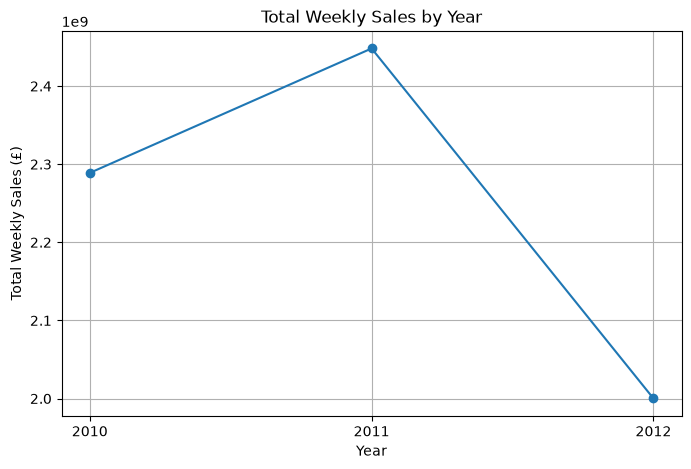

In [296]:
yearly_sales.plot(kind='line', marker='o', figsize=(8, 5))

plt.title('Total Weekly Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Weekly Sales (£)')
plt.xticks([2010, 2011, 2012])
plt.grid(True)

plt.show()

In [297]:
import matplotlib.pyplot as plt

In [298]:
monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Weekly_Sales'].mean()

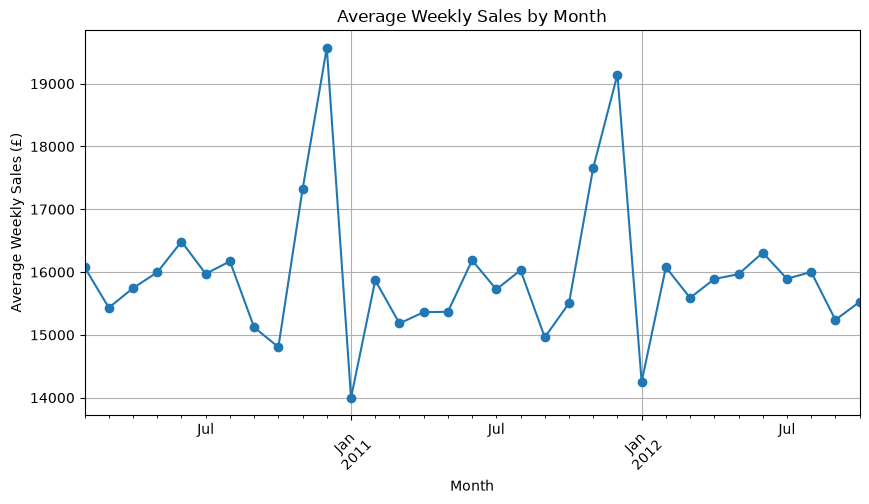

In [299]:
monthly_sales.plot(kind='line', marker='o', figsize=(10, 5))

plt.title('Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales (£)')

plt.grid(True)
plt.xticks(rotation=45)

plt.show()

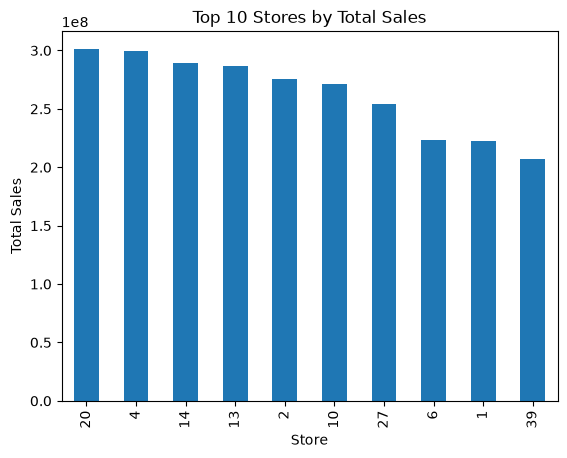

In [300]:
store_sales.head(10).plot(kind='bar')

plt.title('Top 10 Stores by Total Sales')

plt.xlabel('Store')

plt.ylabel('Total Sales')

plt.show()

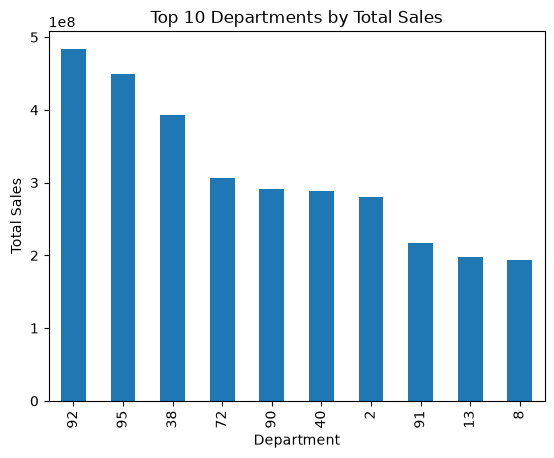

In [301]:
dept_sales.head(10).plot(kind='bar')

plt.title('Top 10 Departments by Total Sales')
plt.xlabel('Department')
plt.ylabel('Total Sales')

plt.show()

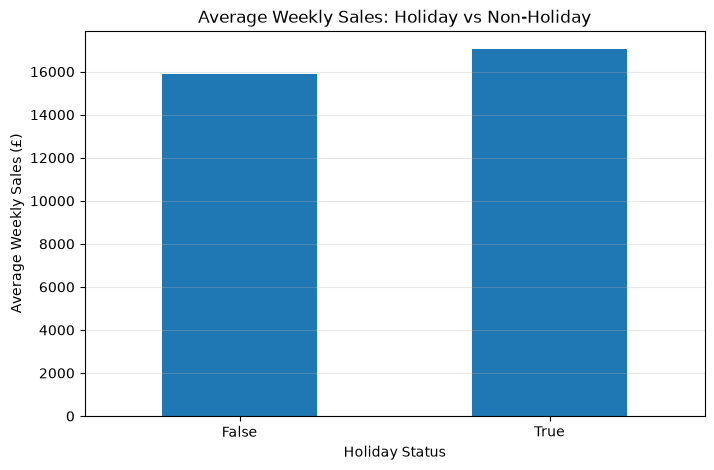

In [302]:
holiday_sales.plot(kind='bar', figsize=(8, 5))

plt.title('Average Weekly Sales: Holiday vs Non-Holiday')
plt.xlabel('Holiday Status')
plt.ylabel('Average Weekly Sales (£)')

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

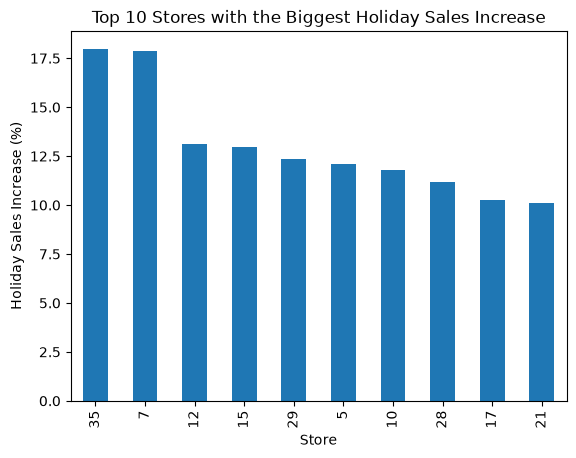

In [303]:
holiday_increase = holiday_comparison['Holiday_Increase_%'].sort_values(ascending=False).head(10)

holiday_increase.plot(kind='bar')

plt.title('Top 10 Stores with the Biggest Holiday Sales Increase')
plt.xlabel('Store')
plt.ylabel('Holiday Sales Increase (%)')

plt.show()

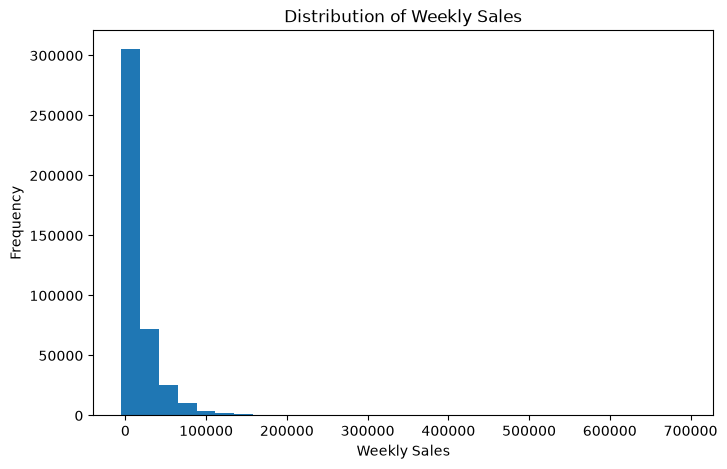

In [304]:
df['Weekly_Sales'].plot(kind='hist', bins=30, figsize=(8, 5))

plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')

plt.show()

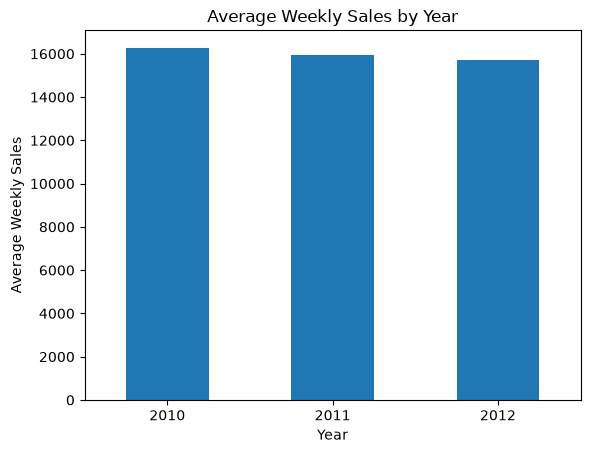

In [305]:
yearly_sales = df.groupby(df['Date'].dt.year)['Weekly_Sales'].mean()

yearly_sales.plot(kind='bar')

plt.title('Average Weekly Sales by Year')
plt.xlabel('Year')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=0)
plt.show()

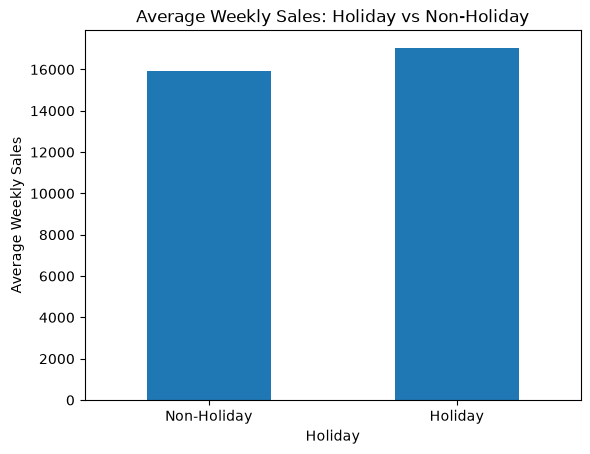

In [306]:
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()

holiday_sales.plot(kind='bar')

plt.title('Average Weekly Sales: Holiday vs Non-Holiday')
plt.xlabel('Holiday')
plt.ylabel('Average Weekly Sales')
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'], rotation=0)

plt.show()

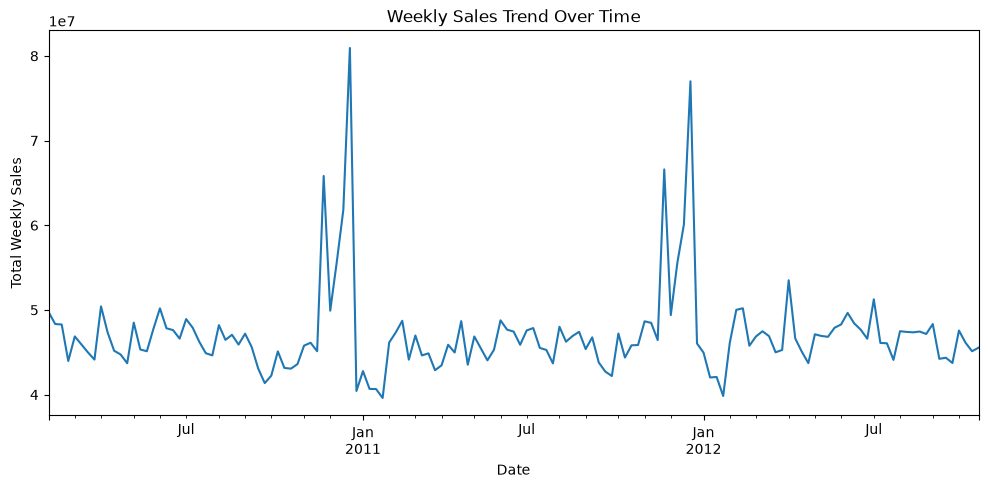

In [307]:
weekly_trend = df.groupby('Date')['Weekly_Sales'].sum()

weekly_trend.plot(figsize=(12, 5))

plt.title('Weekly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.show()

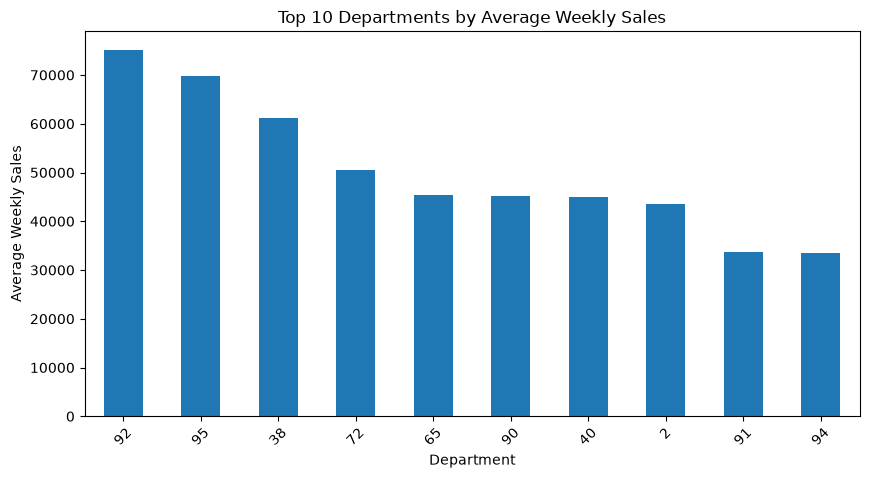

In [308]:
top_departments = (
    df.groupby('Dept')['Weekly_Sales']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_departments.plot(kind='bar', figsize=(10, 5))

plt.title('Top 10 Departments by Average Weekly Sales')
plt.xlabel('Department')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=45)

plt.show()

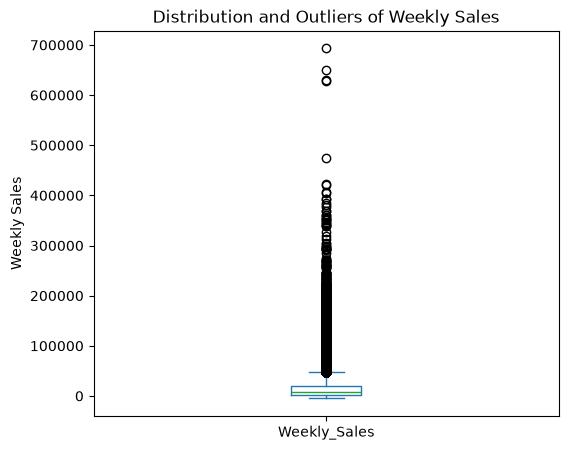

In [309]:
# Box plot to identify the spread and unusual values in weekly sales

df['Weekly_Sales'].plot(kind='box', figsize=(6, 5))

plt.title('Distribution and Outliers of Weekly Sales')
plt.ylabel('Weekly Sales')

plt.show()

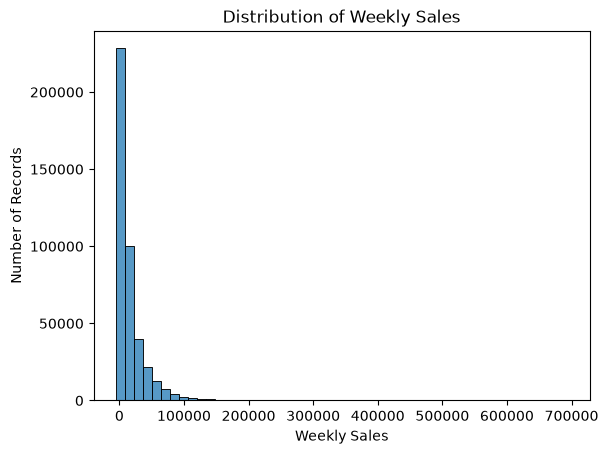

In [310]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='Weekly_Sales', bins=50)

plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Number of Records')
plt.show()

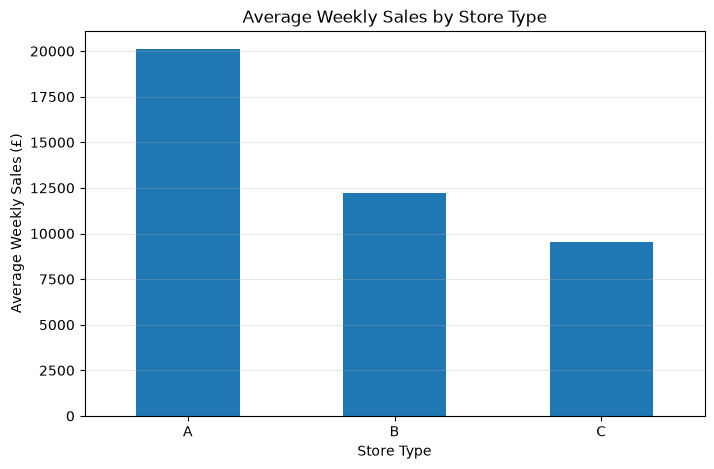

In [311]:
df.groupby('Type')['Weekly_Sales'].mean().sort_values(ascending=False).plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Weekly Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Weekly Sales (£)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

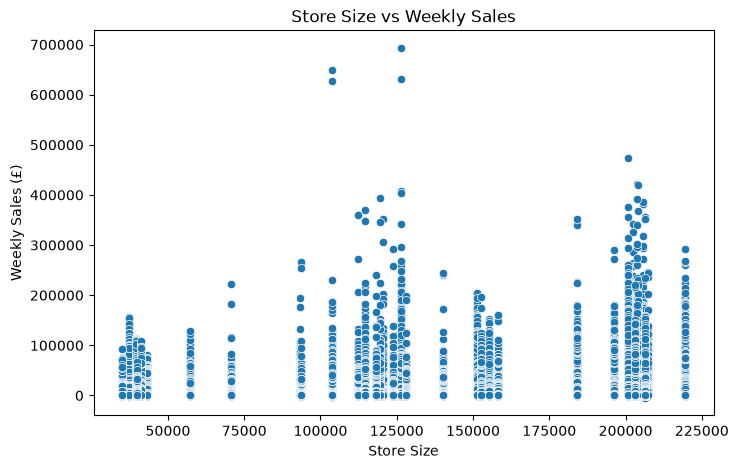

In [312]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Size', y='Weekly_Sales')

plt.title('Store Size vs Weekly Sales')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales (£)')

plt.show()

In [313]:
df['Size'].corr(df['Weekly_Sales'])

np.float64(0.24382799226304497)

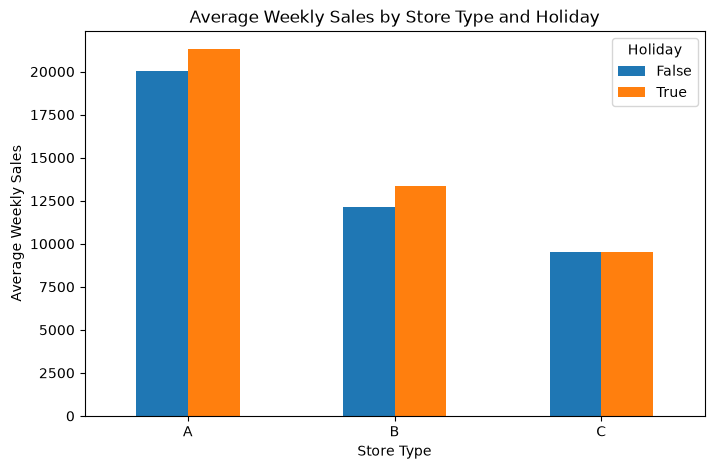

In [314]:
df.groupby(['Type', 'IsHoliday'])['Weekly_Sales'].mean().unstack().plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Weekly Sales by Store Type and Holiday')
plt.xlabel('Store Type')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=0)
plt.legend(title='Holiday')
plt.show()

In [315]:
df.groupby(['Type', 'IsHoliday'])['Weekly_Sales'].mean().unstack()

IsHoliday,False,True
Type,,
A,20008.746759,21297.517824
B,12153.067752,13346.164062
C,9518.528116,9532.963131


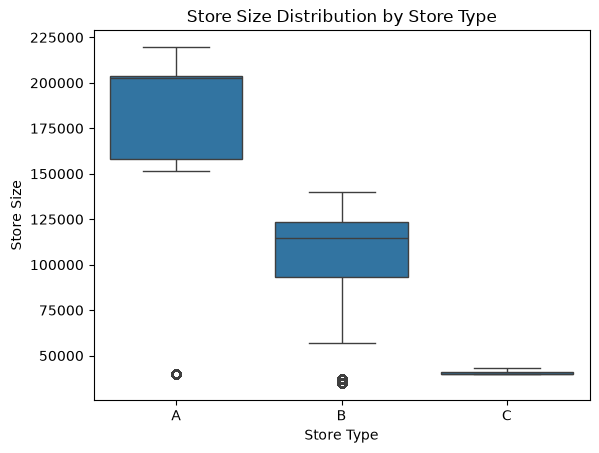

In [316]:
sns.boxplot(data=df, x='Type', y='Size')

plt.title('Store Size Distribution by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Store Size')
plt.show()

In [317]:
df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].sum()

MarkDown1    1.091898e+09
MarkDown2    3.709708e+08
MarkDown3    1.973317e+08
MarkDown4    4.566161e+08
MarkDown5    7.009750e+08
dtype: float64

In [318]:
(df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']] > 0).sum()

MarkDown1    150681
MarkDown2    109730
MarkDown3    136767
MarkDown4    134967
MarkDown5    151432
dtype: int64

In [319]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

df['Markdown_Active'] = (df[markdown_cols].sum(axis=1) > 0)

---

In [320]:
df.groupby('Markdown_Active')['Weekly_Sales'].mean()

Markdown_Active
False    15871.522017
True     16177.015244
Name: Weekly_Sales, dtype: float64

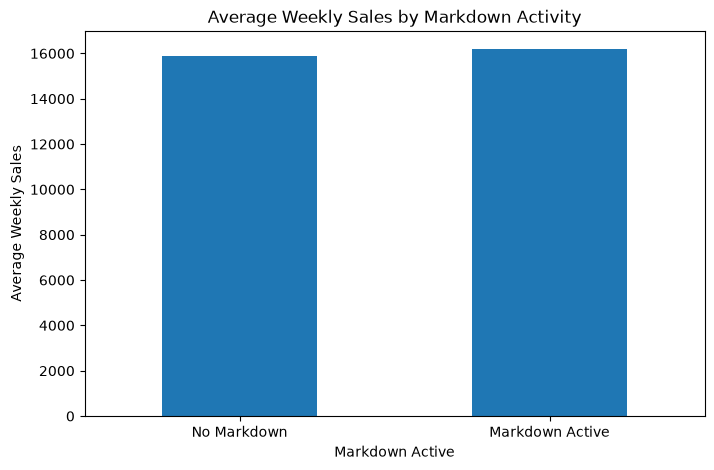

In [321]:
df.groupby('Markdown_Active')['Weekly_Sales'].mean().plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Weekly Sales by Markdown Activity')
plt.xlabel('Markdown Active')
plt.ylabel('Average Weekly Sales')
plt.xticks([0, 1], ['No Markdown', 'Markdown Active'], rotation=0)
plt.show()

In [322]:
df[markdown_cols + ['Weekly_Sales']].corr()['Weekly_Sales'].sort_values(ascending=False)

Weekly_Sales    1.000000
MarkDown5       0.090362
MarkDown1       0.085251
MarkDown3       0.060385
MarkDown4       0.045414
MarkDown2       0.024130
Name: Weekly_Sales, dtype: float64

In [323]:
df['Fuel_Price'].corr(df['Weekly_Sales'])

np.float64(-0.00012029554499574325)

In [324]:
df['CPI'].corr(df['Weekly_Sales'])

np.float64(-0.020921335318819168)

In [325]:
df['Unemployment'].corr(df['Weekly_Sales'])

np.float64(-0.0258637164998377)

In [326]:
df.isna().sum()

Store                   0
Dept                    0
Date                    0
Weekly_Sales            0
IsHoliday_x             0
Type                    0
Size                    0
Temperature             0
Fuel_Price              0
MarkDown1          270889
MarkDown2          310322
MarkDown3          284479
MarkDown4          286603
MarkDown5          270138
CPI                     0
Unemployment            0
IsHoliday               0
Markdown_Active         0
dtype: int64

In [327]:
df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).head(10)

Store
20    29508.301592
4     29161.210415
14    28784.851727
13    27355.136891
2     26898.070031
10    26332.303819
27    24826.984536
6     21913.243624
1     21710.543621
39    21000.763562
Name: Weekly_Sales, dtype: float64

In [329]:
print(df[['Store', 'Weekly_Sales']].dtypes)

Store             int64
Weekly_Sales    float64
dtype: object


In [331]:
df.groupby('Store')['Weekly_Sales'].mean().sort_values().head(1)

Store
5    5053.415813
Name: Weekly_Sales, dtype: float64

In [332]:
df.groupby('Type')['Size'].mean()

Type
A    182231.285486
B    101818.735827
C     40535.725286
Name: Size, dtype: float64

In [333]:
df.groupby(df['Date'].dt.to_period('M'))['Weekly_Sales'].mean().sort_values(ascending=False).head(10)

Date
2010-12    19570.351252
2011-12    19145.218481
2011-11    17659.218122
2010-11    17320.130647
2010-06    16486.250953
2012-06    16309.247563
2011-06    16188.124643
2010-08    16171.689295
2012-02    16077.647710
2010-02    16076.778701
Freq: M, Name: Weekly_Sales, dtype: float64

--------------------------------------------------------------

### SECTION 4
- Findings and Insights
- Limitations of Analysis
- Business Recommendations

### Findings and Insights

#### 1. Sales by Year
The analysis showed that total weekly sales varied across the three years. 2011 recorded the highest total sales, while 2012 recorded a lower total than 2011. This indicates that sales performance changed over time and that the business should monitor yearly trends when evaluating overall performance.

#### 2. Sales by Month

Monthly analysis showed clear seasonal variation in average weekly sales. December recorded particularly strong sales, suggesting increased customer demand towards the end of the year. This highlights the importance of seasonal planning and preparing for periods of increased demand.

#### 3. Top Stores

Store-level analysis showed differences in average weekly sales across stores. Store 20 recorded the highest average weekly sales, followed by Store 4 and Store 14. In contrast, Store 5 recorded the lowest average weekly sales among the lowest-performing stores analysed. This indicates that store performance varies considerably and may be influenced by factors beyond store size alone.

#### 4. Top Departments

Department-level analysis showed significant differences in total sales. Department 92 recorded the highest total weekly sales, followed by Departments 95 and 38. This suggests that certain departments contribute substantially more to overall sales and may require greater attention when planning stock, promotions and resources.

#### 5. Holiday Sales

Average weekly sales were higher during holiday weeks than non-holiday weeks. Holiday weeks recorded average sales of approximately £17,036 compared with approximately £15,901 during non-holiday weeks. This suggests that holiday periods can create increased sales opportunities for the business.

#### 6. Holiday Sales by Store

Holiday performance varied between stores. Some stores experienced a much greater increase in average sales during holiday periods than others. Store 35 recorded the highest holiday sales increase among the stores analysed, at approximately 18%. This suggests that the impact of holidays is not the same across all stores and that individual store performance should be considered when planning holiday strategies.

#### 7. Negative Sales
The analysis identified 1,285 records with negative weekly sales, representing approximately £88,162 in total negative sales. These records may represent returns, refunds, adjustments or possible data-quality issues. Further investigation would therefore be useful before using these records for some types of sales forecasting or performance analysis.

#### 8. Data Quality

The final merged dataset contained 421,570 rows and 16 columns. After the data preparation and merging process, no missing values were identified across the final dataset. The analysis also confirmed that the Date column had been converted to a datetime format and that the datasets were successfully combined using Store and Date. This provided a consistent dataset for further analysis.

#### 9. Store Type and Size
The analysis showed that Type A stores had the highest average weekly sales at approximately £20,100, followed by Type B at approximately £12,237 and Type C at approximately £9,520. Store size had a weak positive correlation with weekly sales of approximately 0.24. This suggests that larger stores may tend to achieve higher sales, but store size alone does not strongly explain differences in sales performance

### Limitations of Analysis

Although the analysis provides useful insights into retail sales performance, there are several limitations to consider.

* **Historical data:** The dataset covers a specific historical period, so the findings may not fully represent current customer behaviour or future sales patterns.

* **Negative sales records:** The dataset contains 1,285 negative sales records. These may represent returns, refunds or data-entry issues, and their exact causes could not be confirmed from the available data.

* **Correlation does not imply causation:** The weak positive correlation between store size and weekly sales does not prove that increasing store size will directly increase sales.

* **Limited customer information:** The dataset does not contain detailed customer-level information, such as customer demographics, purchasing behaviour or individual transactions. This limits the ability to analyse customer preferences in detail.

* **External factors:** Factors such as local competition, marketing campaigns, changes in consumer behaviour and economic conditions may have influenced sales but are not fully captured in the analysis.

* **Markdown information:** Although markdown variables were available, the analysis could not establish a strong causal relationship between markdown activity and sales. Therefore, markdown activity should not be assumed to directly cause changes in weekly sales.

These limitations should be considered when interpreting the findings and applying the recommendations to future business decisions.


### Business Recommendations

#### 1. Improve Performance Across Lower-Performing Store Types

The business should investigate the factors contributing to the stronger performance of Type A stores and identify successful practices that could be adapted for lower-performing store types. Since store size alone has only a weak positive relationship with weekly sales, the business should also consider other factors such as product mix, customer demand, promotions and store operations when developing improvement strategies.

#### 2. Strengthen Holiday Sales Planning

The business should increase inventory, staffing and promotional planning ahead of key holiday periods to take advantage of higher customer demand. Stores could use previous holiday sales patterns to improve stock forecasting and ensure that popular products are available when demand is highest. This could help the business maximise sales while reducing the risk of stock shortages during important holiday periods.

#### 3. Prepare for Seasonal Demand

The business should use historical monthly sales patterns to plan inventory, staffing and promotional campaigns ahead of periods of higher demand, particularly towards the end of the year. Preparing early for seasonal peaks can help stores meet customer demand, minimise stock shortages and maximise potential sales opportunities.

#### 4. Investigate Negative Sales Records
The business should investigate the negative weekly sales records identified in the dataset to determine whether they represent genuine returns, refunds, data-entry errors or other unusual transactions. Understanding the cause of these negative values will improve the reliability of sales reporting and support more accurate business decisions.

#### 5. Monitor Sales Performance Regularly

TThe business should monitor sales performance regularly across stores, departments, holiday periods and seasons. Regular monitoring can help identify changes in customer demand, underperforming areas and emerging sales opportunities, allowing the business to respond quickly and make more informed decisions.

----------------------------------------------------------------

### SECTION 5
### Conclusion

This analysis explored retail sales performance across stores, departments, time periods, holiday periods and store types using historical Walmart sales data. The analysis identified clear differences in sales performance between stores and departments, as well as seasonal and holiday-related changes in customer demand.

The findings showed that 2011 recorded the highest total sales, while December was one of the strongest months for average weekly sales. Type A stores achieved the highest average weekly sales, while Type C stores recorded the lowest. The analysis also found a weak positive relationship between store size and weekly sales, indicating that store size alone does not fully explain sales performance.


-------------------------------------------------------------

## REFERENCES

* **Kaggle** — Retail Data Analytics dataset. Used as the primary dataset for this project and analysis. https://www.kaggle.com/datasets/manjeetsingh/retaildataset

* **Code Institute** — Data Analytics with AI course materials and Capstone Project guidance. https://codeinstitute.net/

* **Code Institute LMS** — Learning materials, exercises and project guidance used throughout the course. https://lms.codeinstitute.net/site/not_logged_in?from=%2Fuser%2Fshow%2F806141&log_in_required=true

* **OpenAI ChatGPT** — Used as an AI assistance tool for understanding concepts, troubleshooting Python code, reviewing analysis approaches and improving project documentation. https://chatgpt.com/

* **QuillBot** — Used to support paraphrasing and improve the clarity and readability of written content. https://quillbot.com/

* **Code** Institute Trainer/Facilitator — Emma Lamont— Guidance, feedback and support provided throughout the project.



---